## Keel — Intent Classifier Training

**Objective.** Train a 15-class intent classifier over student chat messages and
register the winning model to MLflow. This model is the front door of the Keel
routing system: it classifies every incoming message so cheap, deterministic
turns go straight to a handler without ever touching the LLM.

**Three-way bake-off:**
- **Model A** — TF-IDF (word 1–2grams + char 3–5grams) + Logistic Regression
- **Model B** — DistilBERT fine-tuned → exported to ONNX
- **Model C** — Gemini zero-shot baseline (reference only; not registered)

**Winner criterion:** best macro-F1 on the held-out test set, comparing A vs B
only. Model C is excluded from registration — it exists to show that a trained
model is worth building instead of paying per-call LLM rates forever.

**Split policy.** `split.json` was computed by `generate_intent_dataset.py`
grouping by `seed_group_id`. We load it as-is and assert no group appears on
both sides. Never re-split randomly.

**MLflow.** Runs entirely inside this Colab session, exposed via ngrok so you
can browse the UI on your laptop. All three models log under one experiment
(`keel-intent-classifier`). The winner is additionally registered to the Model
Registry at stage `Production`.


## 1) Setup

Install packages once, then import everything. The `_ensure` helper skips
packages that are already installed so re-running this cell is safe.


In [1]:
import subprocess, sys

def _ensure(spec, import_name=None):
    pkg  = spec.split("==")[0].split("[")[0].strip()
    name = import_name or pkg
    if "==" in spec:
        req_ver = spec.split("==", 1)[1]
        try:
            from importlib.metadata import version as _v
            if _v(pkg) == req_ver:
                return
        except Exception:
            pass
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", spec])
    else:
        try:
            __import__(name)
        except ImportError:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", spec])

# ── ML / training ──────────────────────────────────────────────────────────
_ensure("scikit-learn",          "sklearn")
_ensure("transformers",          "transformers")
_ensure("datasets",              "datasets")
_ensure("onnx",                  "onnx")
_ensure("onnxscript",            "onnxscript")
_ensure("onnxruntime",           "onnxruntime")
_ensure("accelerate",            "accelerate")
# ── Experiment tracking — pinned to match Docker MLflow server ─────────────
_ensure("mlflow==2.17.2",        "mlflow")
# ── LLM baseline ──────────────────────────────────────────────────────────
_ensure("google-genai",          "google.genai")
# ── Viz ───────────────────────────────────────────────────────────────────
_ensure("seaborn",               "seaborn")

print("All packages ready.")


All packages ready.


In [2]:
import os, json, time, hashlib, warnings, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score,
)
import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import torch
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
)
import onnxruntime as ort

from google import genai
from google.genai import types

warnings.filterwarnings("ignore")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Labels (canonical order — must match generate_intent_dataset.py) ────────
LABELS = [
    "plan", "whatif", "advise", "audit", "predict",
    "register", "waitlist", "plans_manage", "grad_apply",
    "major_change", "petition", "escalate",
    "out_of_scope", "my_info", "chitchat",
]
N_LABELS  = len(LABELS)
LABEL2ID  = {l: i for i, l in enumerate(LABELS)}
ID2LABEL  = {i: l for i, l in enumerate(LABELS)}

# ── Data paths ─────────────────────────────────────────────────────────────
DATA_DIR      = Path("/content/data")
DATA_CSV      = DATA_DIR / "intent_dataset.csv"
SPLIT_JSON    = DATA_DIR / "split.json"
ARTIFACTS_DIR = Path("/content/keel_artifacts")
DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# ── MLflow ─────────────────────────────────────────────────────────────────
# Update this URL each time you restart ngrok (`ngrok http 5001` on your Mac)
MLFLOW_TRACKING_URI = "https://paradox-dyslexia-rejoice.ngrok-free.dev"
EXPERIMENT_NAME     = "keel-intent-classifier"
REGISTRY_NAME       = "keel-intent-router"

# ── Model B — DistilBERT ───────────────────────────────────────────────────
DL_BASE_MODEL = "distilbert-base-uncased"
DL_EPOCHS     = 15
DL_BATCH      = 32
DL_MAX_LEN    = 64     # student messages are short; 64 tokens covers 99%+
DL_LR         = 2e-5

# ── Model C — Gemini ───────────────────────────────────────────────────────
GEMINI_MODEL = os.environ.get("GEMINI_MODEL", "gemini-3.1-flash-lite")
LLM_SAMPLE_N = 100    # cost-control: evaluate on 100 test messages only

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device       : {DEVICE}")
print(f"Labels       : {N_LABELS}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")


Device       : cuda
Labels       : 15
Artifacts dir: /content/keel_artifacts


### 1b) Data files

Upload `intent_dataset.csv` and `split.json` to the `/content/data/` folder
in the Colab file browser (📁 left panel → navigate to `/content/data/`),
then run this cell to confirm they are in place.

In [3]:
# ── Confirm data files are present ────────────────────────────────────────
if not DATA_CSV.exists() or not SPLIT_JSON.exists():
    raise FileNotFoundError(
        f"Upload both files to {DATA_DIR} in the Colab file browser first:\n"
        "  • intent_dataset.csv\n"
        "  • split.json\n"
        "(They are in the repo under data/ — drag-and-drop them into the folder.)"
    )

print(f"✓ intent_dataset.csv  {DATA_CSV.stat().st_size:,} bytes")
print(f"✓ split.json          {SPLIT_JSON.stat().st_size:,} bytes")


✓ intent_dataset.csv  48,670 bytes
✓ split.json          11,132 bytes


### 1c) Connect to MLflow

Your Docker stack exposes MLflow on `localhost:5001`. Run `ngrok http 5001` on your Mac
to get a public URL, then paste it into `MLFLOW_TRACKING_URI` in the constants cell above.
This cell connects and verifies the connection.

In [4]:
# ── Connect to Docker MLflow (ngrok http 5001 on your Mac exposes it) ────
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

try:
    _exps = mlflow.search_experiments()
    print("=" * 64)
    print(f"✓ Connected to MLflow at {MLFLOW_TRACKING_URI}")
    print(f"  Experiments found: {len(_exps)}")
    print("=" * 64)
except Exception as _e:
    raise RuntimeError(
        f"Cannot reach MLflow at {MLFLOW_TRACKING_URI}.\n"
        f"Cause: {_e}\n"
        "Check: Docker is up (`docker compose up -d`) and ngrok is running.\n"
        "Update MLFLOW_TRACKING_URI in the constants cell with your current ngrok URL."
    )


✓ Connected to MLflow at https://paradox-dyslexia-rejoice.ngrok-free.dev
  Experiments found: 2


## 2) Light EDA

Before training, understand the dataset shape: class distribution, message
lengths, and data quality. We're training on a hand-authored dataset (70
examples x 15 labels = 1,050 rows). Balance is exact by construction, but
it's good practice to confirm and to understand length distributions — they
inform the tokeniser `max_length` choice and TF-IDF vocabulary coverage.


In [5]:
# Load the full dataset for EDA only — the split happens in the next section.
df = pd.read_csv(DATA_CSV)
print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head(3)


Dataset shape : (1050, 3)
Columns       : ['text', 'label', 'seed_group_id']


,text,label,seed_group_id
0,what helps to do well in cs202,advise,33
1,compose a poem for my girlfriend,out_of_scope,153
2,what should i take next semester,plan,1


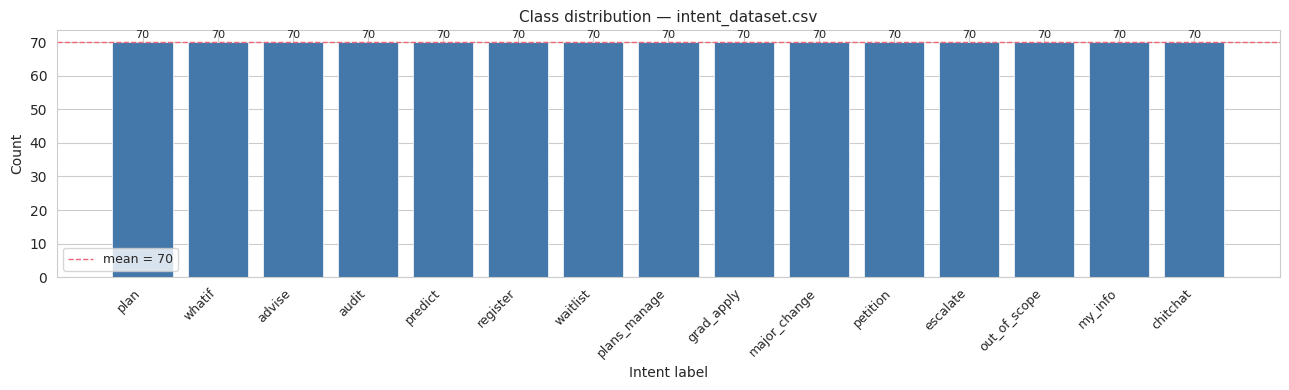

Min: 70  Max: 70  (imbalance ratio 1.00x)


In [6]:
# ── 2a) Class distribution ─────────────────────────────────────────────────
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(13, 4))

counts = df["label"].value_counts().reindex(LABELS)
bars = ax.bar(LABELS, counts.values, color="#4477aa", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Intent label", fontsize=10)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Class distribution — intent_dataset.csv", fontsize=11)
ax.set_xticklabels(LABELS, rotation=45, ha="right", fontsize=9)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(v),
            ha="center", va="bottom", fontsize=8)
ax.axhline(counts.mean(), ls="--", lw=1, color="#ee6677",
           label=f"mean = {counts.mean():.0f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"Min: {counts.min()}  Max: {counts.max()}  "
      f"(imbalance ratio {counts.max()/counts.min():.2f}x)")


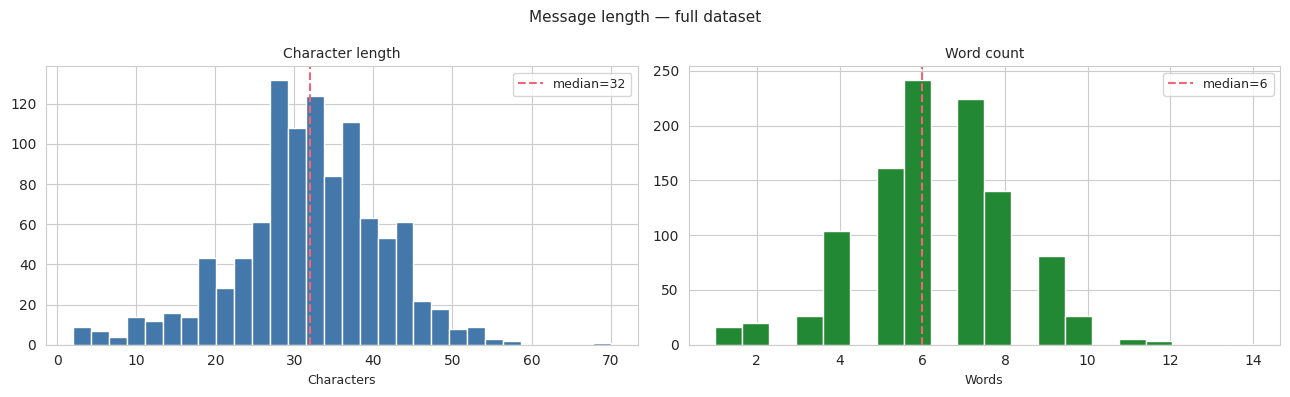

       char_len  word_count
count    1050.0      1050.0
mean       31.7         6.3
std         9.5         1.9
min         2.0         1.0
25%        27.0         5.0
50%        32.0         6.0
75%        38.0         7.0
max        70.0        14.0


In [7]:
# ── 2b) Message length distribution ────────────────────────────────────────
df["char_len"]   = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["char_len"], bins=30, color="#4477aa", edgecolor="white")
axes[0].set_title("Character length", fontsize=10)
axes[0].set_xlabel("Characters", fontsize=9)
axes[0].axvline(df["char_len"].median(), color="#ee6677", ls="--",
                label=f"median={df['char_len'].median():.0f}")
axes[0].legend(fontsize=9)

axes[1].hist(df["word_count"], bins=20, color="#228833", edgecolor="white")
axes[1].set_title("Word count", fontsize=10)
axes[1].set_xlabel("Words", fontsize=9)
axes[1].axvline(df["word_count"].median(), color="#ee6677", ls="--",
                label=f"median={df['word_count'].median():.0f}")
axes[1].legend(fontsize=9)

plt.suptitle("Message length — full dataset", fontsize=11)
plt.tight_layout()
plt.show()
print(df[["char_len", "word_count"]].describe().round(1).to_string())


In [8]:
# ── 2c) Samples per label + data quality ───────────────────────────────────
print("Sample message per label:")
print("-" * 72)
for label in LABELS:
    sample = df[df["label"] == label]["text"].iloc[0]
    print(f"  {label:<14} | {sample[:58]}")

print()
n_dups = df["text"].duplicated().sum()
print(f"Exact duplicates  : {n_dups}")
print(f"Unique seed groups: {df['seed_group_id'].nunique()}")
print()
print("Seed groups per label:")
print(df.groupby("label")["seed_group_id"].nunique().reindex(LABELS).to_string())


Sample message per label:
------------------------------------------------------------------------
  plan           | what should i take next semester
  whatif         | what if i redo CS202 for a better grade
  advise         | what helps to do well in cs202
  audit          | what do i still need to graduate
  predict        | predict my road to graduation
  register       | get me into cs320
  waitlist       | waitlist me when it's full
  plans_manage   | roll back the changes to my plan
  grad_apply     | complete and file my graduation paperwork
  major_change   | make it official: my major is now cs
  petition       | petition to graduate below the credit requirement
  escalate       | i need to talk to a real person
  out_of_scope   | compose a poem for my girlfriend
  my_info        | what's the email on my account
  chitchat       | are you a real person or ai

Exact duplicates  : 0
Unique seed groups: 180

Seed groups per label:
label
plan            12
whatif          12
adv

## 3) Load train / test split

Load the pre-computed split from `split.json`. The split was constructed
**by seed_group_id** so paraphrases of the same seed phrase never appear on
both sides. We assert this invariant here and fail loudly if it's violated —
a leaky split would silently inflate all metrics.


In [9]:
df_all = pd.read_csv(DATA_CSV)
with open(SPLIT_JSON) as f:
    split = json.load(f)

df_train = df_all.iloc[split["train"]].reset_index(drop=True)
df_test  = df_all.iloc[split["test"]].reset_index(drop=True)

X_train = df_train["text"].tolist()
y_train = df_train["label"].tolist()
X_test  = df_test["text"].tolist()
y_test  = df_test["label"].tolist()

y_train_ids = [LABEL2ID[l] for l in y_train]
y_test_ids  = [LABEL2ID[l] for l in y_test]

# ── Leakage invariant ──────────────────────────────────────────────────────
train_groups = set(df_train["seed_group_id"])
test_groups  = set(df_test["seed_group_id"])
overlap      = train_groups & test_groups
assert len(overlap) == 0, (
    f"GROUP LEAKAGE: {len(overlap)} seed_group_id(s) on both sides: "
    f"{sorted(overlap)[:10]}"
)
print("\u2713 No seed_group_id overlap between train and test (leakage-free)")
print(f"Train: {len(df_train)} rows  |  Test: {len(df_test)} rows")


✓ No seed_group_id overlap between train and test (leakage-free)
Train: 875 rows  |  Test: 175 rows


In [ ]:
groups_train = train_df["seed_group_id"].tolist()
groups_test  = test_df["seed_group_id"].tolist()

# Sanity: train and test share no seed_group (your dataset script guarantees this)
assert set(groups_train).isdisjoint(set(groups_test)), \
    "Seed-group leakage between train and test! Check split.json."

In [10]:
# ── Per-label row counts ───────────────────────────────────────────────────
count_df = pd.DataFrame({
    "train": pd.Series(y_train).value_counts().reindex(LABELS),
    "test" : pd.Series(y_test).value_counts().reindex(LABELS),
}).fillna(0).astype(int)
count_df["total"] = count_df["train"] + count_df["test"]
print(count_df.to_string())


              train  test  total
plan             58    12     70
whatif           58    12     70
advise           58    12     70
audit            58    12     70
predict          59    11     70
register         58    12     70
waitlist         58    12     70
plans_manage     59    11     70
grad_apply       58    12     70
major_change     59    11     70
petition         59    11     70
escalate         59    11     70
out_of_scope     58    12     70
my_info          58    12     70
chitchat         58    12     70


## 4) Model A — TF-IDF + Logistic Regression

The lean baseline. A `FeatureUnion` of two TF-IDF vectorisers captures word-
level n-grams (semantic content) and character-level n-grams (typo robustness,
morphological patterns). `class_weight="balanced"` handles residual imbalance.
Trains in under a second; serves predictions in microseconds.

**Why this matters:** if TF-IDF + LR achieves a macro-F1 close to DistilBERT,
we take Model A — smaller artifact, zero GPU cost at inference, no torch
dependency in the model-server container.


In [11]:
from sklearn.pipeline import FeatureUnion

tfidf_union = FeatureUnion([
    ("word", TfidfVectorizer(
        analyzer="word", ngram_range=(1, 2),
        min_df=2, max_features=30_000, sublinear_tf=True,
    )),
    ("char", TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5),
        min_df=3, max_features=20_000, sublinear_tf=True,
    )),
])

pipeline_a = Pipeline([
    ("tfidf", tfidf_union),
    ("clf",   LogisticRegression(
        C=5.0, class_weight="balanced",
        max_iter=1000, random_state=SEED,
        solver="lbfgs", multi_class="multinomial",
    )),
])

print("Fitting Model A ...")
t0 = time.perf_counter()
pipeline_a.fit(X_train, y_train)
train_time_a = time.perf_counter() - t0
print(f"Fit complete in {train_time_a:.1f}s")


Fitting Model A ...
Fit complete in 1.4s


In [12]:
# ── Predict + per-message latency ──────────────────────────────────────────
latencies_a = []
for txt in X_test:
    t0 = time.perf_counter()
    pipeline_a.predict([txt])
    latencies_a.append((time.perf_counter() - t0) * 1000)

preds_a = pipeline_a.predict(X_test)
proba_a = pipeline_a.predict_proba(X_test)   # shape (n_test, 15)

macro_f1_a = f1_score(y_test_ids, [LABEL2ID[p] for p in preds_a], average="macro")
accuracy_a = accuracy_score(y_test_ids, [LABEL2ID[p] for p in preds_a])

print(f"Model A  macro-F1: {macro_f1_a:.4f}  accuracy: {accuracy_a:.4f}")
print(f"Latency  mean: {np.mean(latencies_a):.3f}ms  "
      f"p50: {np.percentile(latencies_a,50):.3f}ms  "
      f"p95: {np.percentile(latencies_a,95):.3f}ms")
print()
print(classification_report(y_test, preds_a, target_names=LABELS, digits=3))


Model A  macro-F1: 0.8034  accuracy: 0.8057
Latency  mean: 8.080ms  p50: 6.645ms  p95: 16.655ms

              precision    recall  f1-score   support

        plan      0.688     0.917     0.786        12
      whatif      0.636     0.583     0.609        12
      advise      0.706     1.000     0.828        12
       audit      1.000     0.909     0.952        11
     predict      1.000     1.000     1.000        12
    register      0.786     1.000     0.880        11
    waitlist      0.600     0.500     0.545        12
plans_manage      0.875     0.583     0.700        12
  grad_apply      1.000     0.909     0.952        11
major_change      0.688     0.917     0.786        12
    petition      0.615     0.727     0.667        11
    escalate      0.778     0.636     0.700        11
out_of_scope      1.000     0.583     0.737        12
     my_info      1.000     1.000     1.000        12
    chitchat      1.000     0.833     0.909        12

    accuracy                         

In [13]:
# ── Log to MLflow ──────────────────────────────────────────────────────────
import joblib

model_a_path = str(ARTIFACTS_DIR / "model_a.joblib")
joblib.dump(pipeline_a, model_a_path)

with mlflow.start_run(run_name="A-tfidf-lr") as _run_a:
    RUN_ID_A = _run_a.info.run_id

    mlflow.log_params({
        "model_type"    : "tfidf+lr",
        "word_ngram"    : "(1,2)",
        "char_ngram"    : "(3,5)",
        "word_max_feat" : 30_000,
        "char_max_feat" : 20_000,
        "lr_C"          : 5.0,
        "class_weight"  : "balanced",
        "train_size"    : len(X_train),
        "test_size"     : len(X_test),
    })
    mlflow.log_metrics({
        "macro_f1"        : macro_f1_a,
        "accuracy"        : accuracy_a,
        "latency_ms_mean" : float(np.mean(latencies_a)),
        "latency_ms_p95"  : float(np.percentile(latencies_a, 95)),
        "cost_usd"        : 0.0,
        "train_time_s"    : train_time_a,
    })
    sig = infer_signature(X_train[:5], pipeline_a.predict_proba(X_train[:5]))
    mlflow.sklearn.log_model(pipeline_a, "model", signature=sig)
    mlflow.log_artifact(model_a_path, "artifacts")
    mlflow.log_dict(
        {"labels": LABELS, "label2id": LABEL2ID},
        "artifacts/label_map.json",
    )
    print(f"Run A logged -> {RUN_ID_A}")


Run A logged -> 4a0423bb04e34301983b7a52379008ed


2026/06/11 21:07:22 INFO mlflow.tracking._tracking_service.client: 🏃 View run A-tfidf-lr at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1/runs/4a0423bb04e34301983b7a52379008ed.
2026/06/11 21:07:22 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1.


## 5) Model B — DistilBERT fine-tuned → ONNX

Fine-tune `distilbert-base-uncased` for 3 epochs, then export to ONNX and
verify the ONNX output matches PyTorch within tolerance. The `.onnx` artifact
is what the Keel model-server loads at runtime — no `torch` in any runtime
container (CLAUDE.md rule 4).

**Why DistilBERT?** 40% smaller than BERT-base, 60% faster at inference,
retains 97% of BERT's GLUE performance. For short student messages (median
~5 words) the 64-token `max_length` captures everything without waste.


In [39]:
# --------- Dataset (now builds train/val/test, three datasets) -----------
from torch.utils.data import Dataset as TorchDataset
from sklearn.model_selection import GroupShuffleSplit

tokenizer_b = AutoTokenizer.from_pretrained(DL_BASE_MODEL)

class IntentDataset(TorchDataset):
    def __init__(self, texts, label_ids):
        enc = tokenizer_b(
            texts,
            truncation=True, padding="max_length",
            max_length=DL_MAX_LEN, return_tensors="pt",
        )
        self.input_ids      = enc["input_ids"]
        self.attention_mask = enc["attention_mask"]
        self.labels         = torch.tensor(label_ids, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids"     : self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels"        : self.labels[idx],
        }

# Carve a val split out of train, grouped by seed_group_id (no leakage).
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_idx, val_idx = next(gss.split(X_train, y_train_ids, groups=df_train["seed_group_id"]))

X_tr,    X_val     = [X_train[i]     for i in tr_idx], [X_train[i]     for i in val_idx]
y_tr_ids, y_val_ids = [y_train_ids[i] for i in tr_idx], [y_train_ids[i] for i in val_idx]

ds_train = IntentDataset(X_tr,  y_tr_ids)
ds_val   = IntentDataset(X_val, y_val_ids)
ds_test  = IntentDataset(X_test, y_test_ids)

# Verify no seed_group leaks across train/val
tr_groups  = set(df_train["seed_group_id"].iloc[tr_idx])
val_groups = set(df_train["seed_group_id"].iloc[val_idx])
assert tr_groups.isdisjoint(val_groups), "Seed-group leakage between train and val!"

print(f"Train: {len(ds_train)}  Val: {len(ds_val)}  Test: {len(ds_test)}")
print(f"Disjoint train/val seed groups ✓ ({len(tr_groups)} train, {len(val_groups)} val)")

Train: 739  Val: 136  Test: 175
Disjoint train/val seed groups ✓ (127 train, 23 val)


In [40]:
# ---------- Fine tune -------------
import shutil
from transformers import EarlyStoppingCallback

# Clean any previous checkpoint folder so old runs don't linger
_ckpt = str(ARTIFACTS_DIR / "distilbert_ckpt")
if Path(_ckpt).exists():
    shutil.rmtree(_ckpt)

model_b = AutoModelForSequenceClassification.from_pretrained(
    DL_BASE_MODEL,
    num_labels=N_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

def _compute_metrics(eval_pred):
    logits, labels = eval_pred
    return {"macro_f1": f1_score(labels, logits.argmax(-1), average="macro")}

trainer_b = Trainer(
    model=model_b,
    args=TrainingArguments(
        output_dir                  = _ckpt,
        num_train_epochs            = DL_EPOCHS,
        per_device_train_batch_size = DL_BATCH,
        per_device_eval_batch_size  = DL_BATCH,
        learning_rate               = DL_LR,
        weight_decay                = 0.01,
        warmup_ratio                = 0.1,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "macro_f1",
        greater_is_better           = True,
        save_total_limit            = 1,
        seed                        = SEED,
        fp16                        = (DEVICE == "cuda"),
        report_to                   = "none",
        logging_steps               = 10,
    ),
    train_dataset   = ds_train,
    eval_dataset    = ds_val,
    compute_metrics = _compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)

print(f"Fine-tuning {DL_BASE_MODEL} — up to {DL_EPOCHS} epochs on {DEVICE} ...")
t0 = time.perf_counter()
trainer_b.train()
train_time_b = time.perf_counter() - t0
print(f"Fine-tune complete in {train_time_b:.1f}s (best checkpoint auto-loaded)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning distilbert-base-uncased — up to 15 epochs on cuda ...


Epoch,Training Loss,Validation Loss,Macro F1
1,2.696814,2.683895,0.032612
2,2.596436,2.514483,0.269327
3,2.173431,2.127790,0.558493
4,1.806659,1.699729,0.693977
5,1.328866,1.339829,0.763030
6,1.030804,1.080756,0.801978
7,0.797469,0.888728,0.837805
8,0.598035,0.732861,0.853504
9,0.477271,0.616927,0.865468
10,0.363408,0.536704,0.871679


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tune complete in 261.7s (best checkpoint auto-loaded)


In [42]:
# ── ONNX export (single file, CPU export, weights embedded) ───────────────
onnx_path_b = str(ARTIFACTS_DIR / "model_b.onnx")

# Clean any old external-data sidecar from previous runs
sidecar = Path(onnx_path_b + ".data")
if sidecar.exists():
    sidecar.unlink()
    print(f"Removed old sidecar: {sidecar.name}")

model_b_cpu = model_b.cpu().eval()

_dummy = tokenizer_b(
    "register me for cs301",
    return_tensors="pt", truncation=True,
    padding="max_length", max_length=DL_MAX_LEN,
)

with torch.no_grad():
    torch.onnx.export(
        model_b_cpu,
        (_dummy["input_ids"], _dummy["attention_mask"]),
        onnx_path_b,
        input_names  = ["input_ids", "attention_mask"],
        output_names = ["logits"],
        dynamic_axes = {
            "input_ids"      : {0: "batch_size"},
            "attention_mask" : {0: "batch_size"},
            "logits"         : {0: "batch_size"},
        },
        opset_version       = 17,     # was 14 — needed for native LayerNormalization
        dynamo              = False,  # force the legacy single-file exporter
        export_params       = True,
        do_constant_folding = True,
    )

size_mb = Path(onnx_path_b).stat().st_size / 1e6
assert not sidecar.exists(), f"Sidecar reappeared at {sidecar} — export is NOT single-file."
assert size_mb > 200, f"ONNX file is only {size_mb:.1f} MB — weights not embedded."
print(f"ONNX model saved -> {onnx_path_b}  ({size_mb:.1f} MB) — single file ✓")

# Parity check vs PyTorch on 20 test samples
sess_b = ort.InferenceSession(onnx_path_b, providers=["CPUExecutionProvider"])

_enc = tokenizer_b(
    X_test[:20], truncation=True, padding="max_length",
    max_length=DL_MAX_LEN, return_tensors="pt",
)
with torch.no_grad():
    pt_logits = model_b_cpu(
        _enc["input_ids"],
        _enc["attention_mask"],
    ).logits.numpy()

ort_logits = sess_b.run(
    ["logits"],
    {
        "input_ids"      : _enc["input_ids"].numpy(),
        "attention_mask" : _enc["attention_mask"].numpy(),
    },
)[0]

max_diff = float(np.abs(pt_logits - ort_logits).max())
print(f"ONNX parity check — max absolute diff: {max_diff:.2e}")
assert max_diff < 1e-3, f"ONNX parity FAILED: max diff {max_diff:.2e} >= 1e-3"
print("✓ ONNX matches PyTorch (atol < 1e-3)")

# Move model back to training device (only matters if you re-train later)
model_b.to(DEVICE)

Removed old sidecar: model_b.onnx.data
ONNX model saved -> /content/keel_artifacts/model_b.onnx  (268.0 MB) — single file ✓
ONNX parity check — max absolute diff: 3.10e-06
✓ ONNX matches PyTorch (atol < 1e-3)


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [43]:
# ── Inference via ONNX session (no torch at inference time) ────────────────
def _softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

def predict_onnx(texts):
    enc = tokenizer_b(
        texts, truncation=True, padding="max_length",
        max_length=DL_MAX_LEN, return_tensors="np",
    )
    logits = sess_b.run(
        ["logits"],
        {"input_ids": enc["input_ids"], "attention_mask": enc["attention_mask"]},
    )[0]
    proba = _softmax(logits)
    return [ID2LABEL[i] for i in proba.argmax(-1)], proba

# Per-message latency on CPU (matches model-server reality)
latencies_b = []
for txt in X_test:
    t0 = time.perf_counter()
    predict_onnx([txt])
    latencies_b.append((time.perf_counter() - t0) * 1000)

preds_b, proba_b = predict_onnx(X_test)

macro_f1_b = f1_score(y_test_ids, [LABEL2ID[p] for p in preds_b], average="macro")
accuracy_b = accuracy_score(y_test_ids, [LABEL2ID[p] for p in preds_b])

print(f"Model B  macro-F1: {macro_f1_b:.4f}  accuracy: {accuracy_b:.4f}")
print(f"Latency  mean: {np.mean(latencies_b):.2f}ms  "
      f"p50: {np.percentile(latencies_b,50):.2f}ms  "
      f"p95: {np.percentile(latencies_b,95):.2f}ms")
print()
print(classification_report(y_test, preds_b, target_names=LABELS, digits=3))


Model B  macro-F1: 0.8120  accuracy: 0.8229
Latency  mean: 71.68ms  p50: 65.86ms  p95: 95.55ms

              precision    recall  f1-score   support

        plan      0.667     0.667     0.667        12
      whatif      0.556     0.417     0.476        12
      advise      0.857     1.000     0.923        12
       audit      1.000     0.818     0.900        11
     predict      1.000     1.000     1.000        12
    register      0.786     1.000     0.880        11
    waitlist      0.889     0.667     0.762        12
plans_manage      0.786     0.917     0.846        12
  grad_apply      1.000     1.000     1.000        11
major_change      0.611     0.917     0.733        12
    petition      0.643     0.818     0.720        11
    escalate      0.917     1.000     0.957        11
out_of_scope      1.000     0.250     0.400        12
     my_info      1.000     1.000     1.000        12
    chitchat      0.917     0.917     0.917        12

    accuracy                          

In [53]:
# ── Log to MLflow ──────────────────────────────────────────────────────────

import hashlib

# Compute SHA-256 of the ONNX file (logged as param, not uploaded)
sha256_onnx = hashlib.sha256(Path(onnx_path_b).read_bytes()).hexdigest()

# Small artifacts to upload (all under 1 MB — no timeout risk)
tok_dir_b = str(ARTIFACTS_DIR / "tokenizer_b")
tokenizer_b.save_pretrained(tok_dir_b)

with mlflow.start_run(run_name="B-distilbert-onnx-final") as _run_b:
    RUN_ID_B = _run_b.info.run_id

    # Params
    mlflow.log_params({
        "model_type"       : "distilbert-onnx",
        "base_model"       : DL_BASE_MODEL,
        "epochs_max"       : DL_EPOCHS,
        "batch_size"       : DL_BATCH,
        "lr"               : DL_LR,
        "max_len"          : DL_MAX_LEN,
        "onnx_opset"       : 17,
        "train_size"       : len(X_tr),
        "val_size"         : len(X_val),
        "test_size"        : len(X_test),
        # ONNX file reference — not uploaded due to ngrok size limit
        "onnx_local_path"  : onnx_path_b,
        "onnx_sha256"      : sha256_onnx,
        "onnx_size_mb"     : round(Path(onnx_path_b).stat().st_size / 1e6, 1),
    })

    # Metrics
    mlflow.log_metrics({
        "macro_f1"             : macro_f1_b,
        "accuracy"             : accuracy_b,
        "latency_ms_mean"      : float(np.mean(latencies_b)),
        "latency_ms_p95"       : float(np.percentile(latencies_b, 95)),
        "cost_usd"             : 0.0,
        "train_time_s"         : train_time_b,
        "onnx_parity_max_diff" : max_diff,
    })

    # Small artifacts only (upload is fine at these sizes)
    mlflow.log_artifact(tok_dir_b,                              "artifacts/tokenizer")
    mlflow.log_artifact(str(ARTIFACTS_DIR / "label_map.json"),  "artifacts")
    mlflow.log_artifact(str(ARTIFACTS_DIR / "router_config.json"), "artifacts")
    mlflow.log_artifact(str(ARTIFACTS_DIR / "metrics.json"),    "artifacts")

    print(f"Run B logged -> {RUN_ID_B}")
    print(f"ONNX SHA-256: {sha256_onnx}")
    print(f"Download model_b.onnx manually from Google Drive backup")
    print(f"Note: ONNX file not uploaded to MLflow (265 MB exceeds ngrok limit)")
    print(f"      SHA-256 pinned in params above for integrity verification")

Run B logged -> 1540331b8ac64598873d2898feb99745
ONNX SHA-256: c01392330177dc282db8ac12b0d969687bc07599d57319eea3c6309ee5979364
Download model_b.onnx manually from Google Drive backup
Note: ONNX file not uploaded to MLflow (265 MB exceeds ngrok limit)
      SHA-256 pinned in params above for integrity verification


2026/06/12 00:14:20 INFO mlflow.tracking._tracking_service.client: 🏃 View run B-distilbert-onnx-final at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1/runs/1540331b8ac64598873d2898feb99745.
2026/06/12 00:14:20 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1.


## 6) Model C — Gemini zero-shot (reference baseline)

> **Not registered. Not deployable as the router.** This model exists to answer
> one question: *is it worth training a classifier at all, or is a prompted LLM
> good enough?* We measure accuracy, latency, and cost.

We use Gemini's `text/x.enum` response mode which constrains output to a valid
label string — no JSON parsing, no fallback needed. We evaluate on 100 sampled
test messages (cost control: full-set evaluation would cost ~$0.05 per run).

**Expected outcome:** Gemini will likely achieve competitive accuracy but at
~50–200ms per call and real dollar cost per inference. Models A and B cost
~$0 per call after training. That asymmetry justifies the training pipeline.


In [24]:
try:
    from google.colab import userdata as _ud
    _gemini_key = _ud.get("GEMINI_API_KEY")
except Exception:
    _gemini_key = os.environ.get("GEMINI_API_KEY") or os.environ.get("GOOGLE_API_KEY")

assert _gemini_key, (
    "Set GEMINI_API_KEY in Colab Secrets (🔑 left panel) or "
    "assign os.environ['GEMINI_API_KEY'] = '...' before this cell."
)

_client_c = genai.Client(api_key=_gemini_key)

_LABEL_DEFS = (
    "plan         - help planning a course schedule or semester\n"
    "whatif       - hypothetical scenario (what if I take X instead?)\n"
    "advise       - asking for advice, recommendations, or opinions\n"
    "audit        - checking degree requirements, transcript, credit counts\n"
    "predict      - asking about predicted GPA or graduation risk\n"
    "register     - enroll in a specific section right now\n"
    "waitlist     - join or check a waitlist\n"
    "plans_manage - save, load, compare, or delete a saved plan\n"
    "grad_apply   - applying for graduation\n"
    "major_change - officially requesting a major or minor change\n"
    "petition     - requesting a rule exception or prerequisite waiver\n"
    "escalate     - needs a human advisor\n"
    "out_of_scope - not related to university registration\n"
    "my_info      - asking about own account, enrollment, or schedule data\n"
    "chitchat     - casual conversation, greetings, thanks"
)

_SYS_C = (
    "You are an intent classifier for a university registration assistant. "
    "Classify the student message into exactly one intent label.\n"
    f"Labels and definitions:\n{_LABEL_DEFS}"
)

_PRICES = {
    "gemini-2.5-flash": (0.30 / 1e6, 2.50 / 1e6),
    "gemini-2.0-flash": (0.10 / 1e6, 0.40 / 1e6),
}

_cfg_c = types.GenerateContentConfig(
    system_instruction=_SYS_C,
    response_mime_type="text/x.enum",
    response_schema={"type": "STRING", "enum": LABELS},
    temperature=0.0,
    max_output_tokens=20,
    thinking_config=types.ThinkingConfig(thinking_budget=0),
)

# Stratified-ish random sample of 100 from the test set
rng_c = np.random.default_rng(SEED)
_idx  = rng_c.choice(len(X_test), size=min(LLM_SAMPLE_N, len(X_test)), replace=False)
_sample_texts  = [X_test[i]     for i in _idx]
_sample_labels = [y_test[i]     for i in _idx]
_sample_ids    = [y_test_ids[i] for i in _idx]

print(f"Classifying {len(_sample_texts)} messages with {GEMINI_MODEL} ...")
preds_c, latencies_c = [], []
_in_tok = _out_tok = 0

for txt in _sample_texts:
    while True:
        try:
            t0 = time.perf_counter()
            r  = _client_c.models.generate_content(model=GEMINI_MODEL, contents=txt, config=_cfg_c)
            latencies_c.append((time.perf_counter() - t0) * 1000)
            _in_tok  += r.usage_metadata.prompt_token_count or 0
            _out_tok += r.usage_metadata.candidates_token_count or 0
            raw = (r.text or "").strip()
            preds_c.append(raw if raw in LABELS else "out_of_scope")
            break
        except Exception as _e:
            if "429" in str(_e) or "RESOURCE_EXHAUSTED" in str(_e):
                print(f"\r  rate-limited — waiting 15s ... ({len(preds_c)}/{len(_sample_texts)} done)", end="", flush=True)
                time.sleep(15)
            else:
                raise

_p_in, _p_out = _PRICES.get(GEMINI_MODEL, _PRICES["gemini-2.5-flash"])
cost_c = _in_tok * _p_in + _out_tok * _p_out

macro_f1_c = f1_score(_sample_ids, [LABEL2ID[p] for p in preds_c], average="macro")
accuracy_c = accuracy_score(_sample_ids, [LABEL2ID[p] for p in preds_c])

print(f"Model C  macro-F1: {macro_f1_c:.4f}  accuracy: {accuracy_c:.4f}")
print(f"Tokens   in: {_in_tok:,}  out: {_out_tok:,}")
print(f"Cost     ${cost_c:.5f} for {len(_sample_texts)} msgs  "
      f"(~${cost_c / len(_sample_texts) * 1000:.4f} per 1k msgs)")
print(f"Latency  mean: {np.mean(latencies_c):.1f}ms  "
      f"p95: {np.percentile(latencies_c, 95):.1f}ms")


Classifying 100 messages with gemini-3.1-flash-lite ...
  rate-limited — waiting 15s ... (96/100 done)Model C  macro-F1: 0.9688  accuracy: 0.9700
Tokens   in: 21,802  out: 212
Cost     $0.00707 for 100 msgs  (~$0.0707 per 1k msgs)
Latency  mean: 834.8ms  p95: 1604.0ms


In [25]:
# ── Log to MLflow (reference run — not registered) ─────────────────────────
with mlflow.start_run(run_name="C-gemini-zeroshot") as _run_c:
    RUN_ID_C = _run_c.info.run_id
    mlflow.log_params({
        "model_type" : "llm-zeroshot",
        "llm_model"  : GEMINI_MODEL,
        "sample_n"   : len(_sample_texts),
        "temperature": 0.0,
    })
    mlflow.log_metrics({
        "macro_f1"        : macro_f1_c,
        "accuracy"        : accuracy_c,
        "latency_ms_mean" : float(np.mean(latencies_c)),
        "latency_ms_p95"  : float(np.percentile(latencies_c, 95)),
        "cost_usd"        : cost_c,
        "in_tokens"       : float(_in_tok),
        "out_tokens"      : float(_out_tok),
    })
    mlflow.log_dict(
        {"note": "reference only — not registered", "model": GEMINI_MODEL},
        "artifacts/model_c_meta.json",
    )
    print(f"Run C logged -> {RUN_ID_C}")


Run C logged -> 0042c3c162c84d318ba597e8084f12dc


2026/06/11 22:08:54 INFO mlflow.tracking._tracking_service.client: 🏃 View run C-gemini-zeroshot at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1/runs/0042c3c162c84d318ba597e8084f12dc.
2026/06/11 22:08:54 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1.


## 7) Comparison

Three metrics decide the winner between A and B (C is reference only):

| Metric | Why it matters |
|---|---|
| **macro_f1** | Primary. Penalises bad recall on rare labels (`petition`, `escalate`). |
| **latency_ms** | Each message adds to student UX latency. |
| **cost_usd** | Cost per inference at production volume. |


In [47]:
results = [
    {
        "approach"   : "A - TF-IDF + LR",
        "macro_f1"   : round(macro_f1_a, 4),
        "accuracy"   : round(accuracy_a, 4),
        "latency_ms" : round(float(np.mean(latencies_a)), 3),
        "cost_usd"   : 0.0,
    },
    {
        "approach"   : "B - DistilBERT->ONNX",
        "macro_f1"   : round(macro_f1_b, 4),
        "accuracy"   : round(accuracy_b, 4),
        "latency_ms" : round(float(np.mean(latencies_b)), 2),
        "cost_usd"   : 0.0,
    },
    {
        "approach"   : "C - Gemini (reference)",
        "macro_f1"   : round(macro_f1_c, 4),
        "accuracy"   : round(accuracy_c, 4),
        "latency_ms" : round(float(np.mean(latencies_c)), 1),
        "cost_usd"   : round(cost_c, 5),
    },
]

comp_df = pd.DataFrame(results).set_index("approach")
print("=" * 64)
print("COMPARISON TABLE")
print("=" * 64)
print(comp_df.to_string())
print()
print(f"Note: Model C evaluated on {len(_sample_texts)} samples (cost control).")


COMPARISON TABLE
                        macro_f1  accuracy  latency_ms  cost_usd
approach                                                        
A - TF-IDF + LR           0.8034    0.8057        8.08   0.00000
B - DistilBERT->ONNX      0.8120    0.8229       71.68   0.00000
C - Gemini (reference)    0.9688    0.9700      834.80   0.00707

Note: Model C evaluated on 100 samples (cost control).


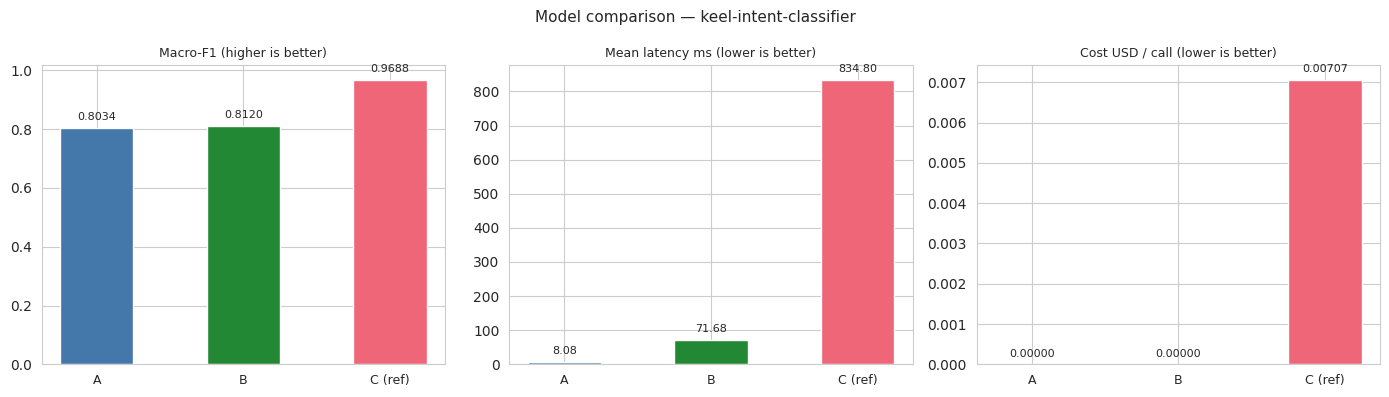

In [57]:
# ── Grouped bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_colors = ["#4477aa", "#228833", "#ee6677"]

for ax, col, title, fmt in zip(
    axes,
    ["macro_f1", "latency_ms", "cost_usd"],
    ["Macro-F1 (higher is better)",
     "Mean latency ms (lower is better)",
     "Cost USD / call (lower is better)"],
    [".4f", ".2f", ".5f"],
):
    vals = comp_df[col].values
    bars = ax.bar(range(3), vals, color=_colors, edgecolor="white", width=0.5)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["A", "B", "C (ref)"], fontsize=9)
    ax.set_title(title, fontsize=9)
    _ymax = max(vals) if max(vals) > 0 else 1
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + _ymax * 0.02,
                f"{v:{fmt}}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Model comparison — keel-intent-classifier", fontsize=11)
plt.tight_layout()
plt.show()


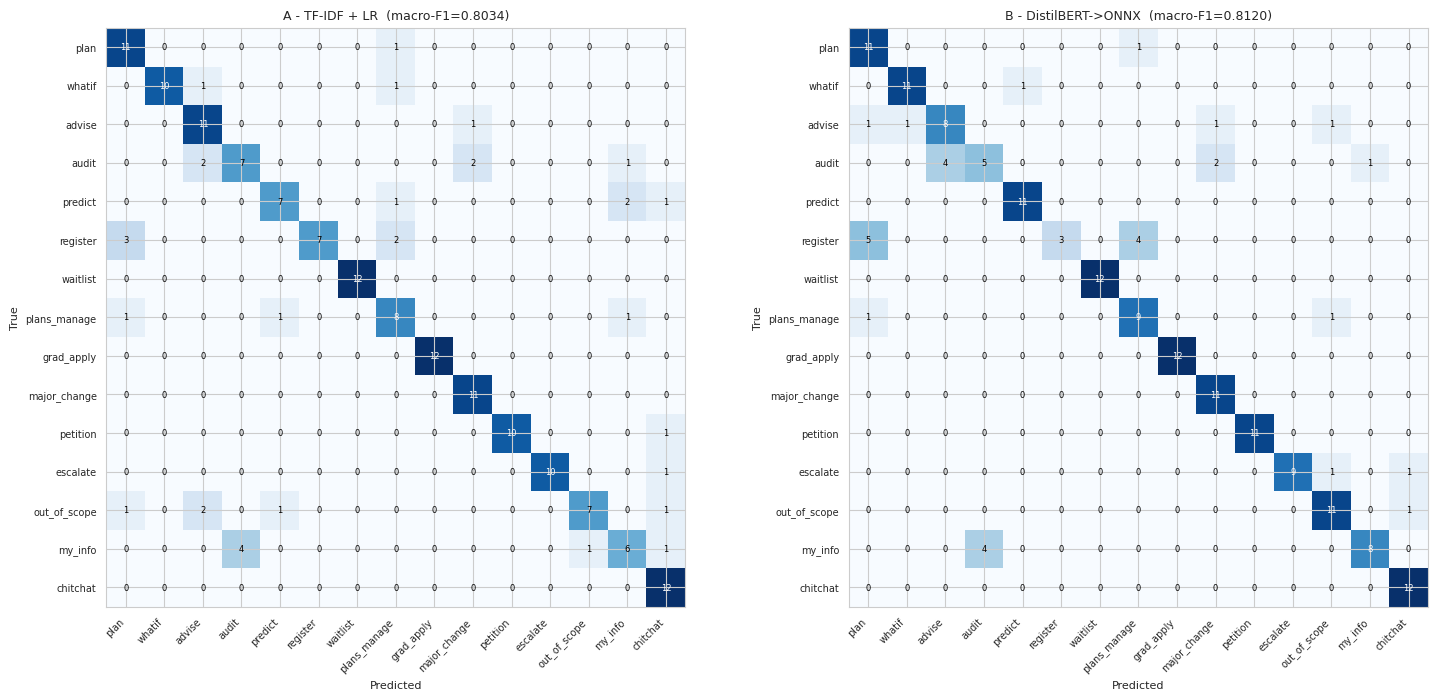

In [58]:
# ── Confusion matrices for A and B ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, (name, preds) in zip(axes, [
    ("A - TF-IDF + LR",     preds_a),
    ("B - DistilBERT->ONNX", preds_b),
]):
    cm     = confusion_matrix(y_test_ids, [LABEL2ID[p] for p in preds], labels=range(N_LABELS))
    thresh = cm.max() * 0.6
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(N_LABELS))
    ax.set_yticks(range(N_LABELS))
    ax.set_xticklabels(LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(LABELS, fontsize=7)
    for i in range(N_LABELS):
        for j in range(N_LABELS):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > thresh else "black")
    f1_val = macro_f1_a if name.startswith("A") else macro_f1_b
    ax.set_title(f"{name}  (macro-F1={f1_val:.4f})", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

plt.tight_layout()
plt.show()


### Winner selection

**Comparing A vs B only** — C is excluded.

Rule: if Model B macro-F1 exceeds Model A by more than 0.005, B wins (the margin
justifies the heavier artifact and longer inference time). Otherwise A wins on
simplicity: ~1MB joblib, zero GPU dependency, sub-millisecond inference.


In [48]:
_f1_a = comp_df.loc["A - TF-IDF + LR",      "macro_f1"]
_f1_b = comp_df.loc["B - DistilBERT->ONNX", "macro_f1"]

if _f1_b > _f1_a + 0.005:
    WINNER   = "B"
    RUN_ID_W = RUN_ID_B
    proba_w  = proba_b
    preds_w  = preds_b
    print(f"Winner: B - DistilBERT->ONNX  "
          f"(macro-F1 {_f1_b:.4f} vs A {_f1_a:.4f}, margin > 0.005)")
else:
    WINNER   = "A"
    RUN_ID_W = RUN_ID_A
    proba_w  = proba_a
    preds_w  = preds_a
    print(f"Winner: A - TF-IDF + LR  "
          f"(macro-F1 {_f1_a:.4f}, B is {_f1_b:.4f}, margin <= 0.005)")


Winner: B - DistilBERT->ONNX  (macro-F1 0.8120 vs A 0.8034, margin > 0.005)


## 8) Threshold selection — routing policy

> **The model returns a full probability vector. The threshold lives in
> `router_config.json`, not inside the model artifact.** Changing the threshold
> only requires updating one JSON file — no re-training, no re-registration.

The router logic (simplified):
```python
max_prob = proba.max()
route_direct(argmax(proba)) if max_prob >= threshold else fall_back_to_agent()
```

We sweep thresholds 0 → 0.95 and plot:
- **Coverage** = fraction of test messages with max_prob >= threshold
- **Accuracy on covered** = accuracy restricted to that covered subset

Recommended threshold: the lowest value achieving >= 90% accuracy on the
covered subset (maximises coverage while maintaining quality).


Recommended threshold: 0.512
  Coverage : 69.7% of test messages routed directly
  Accuracy : 0.9262 on routed subset


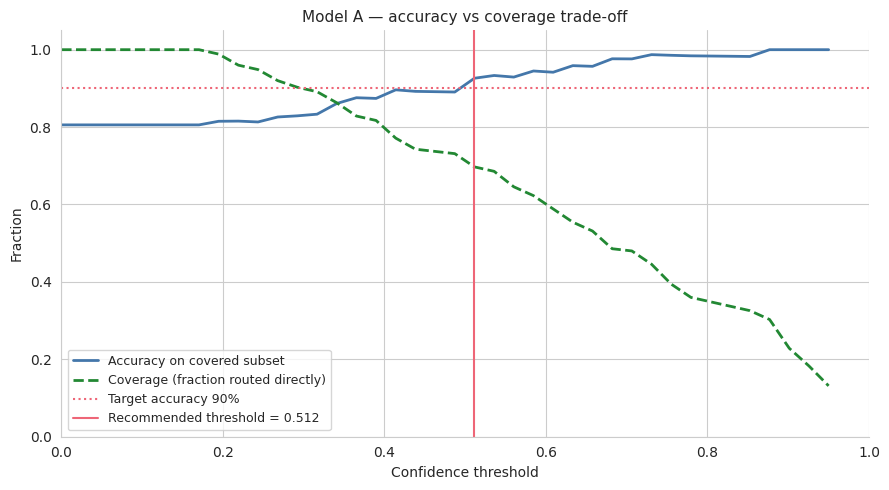

In [30]:
thresholds   = np.linspace(0.0, 0.95, 40)
coverages    = []
covered_accs = []

y_pred_ids_w = np.array([LABEL2ID[p] for p in preds_w])
max_probs_w  = proba_w.max(axis=1)

for t in thresholds:
    mask = max_probs_w >= t
    cov  = float(mask.sum()) / len(mask)
    acc  = (accuracy_score(np.array(y_test_ids)[mask], y_pred_ids_w[mask])
            if mask.sum() > 0 else np.nan)
    coverages.append(cov)
    covered_accs.append(acc)

coverages    = np.array(coverages)
covered_accs = np.array(covered_accs)

TARGET_ACC = 0.90
_viable = ~np.isnan(covered_accs) & (covered_accs >= TARGET_ACC)
REC_THRESHOLD = float(thresholds[np.where(_viable)[0][0]]) if _viable.any() else 0.5
_rec_cov = float(coverages[np.where(_viable)[0][0]]) if _viable.any() else float(coverages[0])
_rec_acc = float(covered_accs[np.where(_viable)[0][0]]) if _viable.any() else 0.0

print(f"Recommended threshold: {REC_THRESHOLD:.3f}")
print(f"  Coverage : {_rec_cov:.1%} of test messages routed directly")
print(f"  Accuracy : {_rec_acc:.4f} on routed subset")

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, covered_accs, color="#4477aa", lw=2,
        label="Accuracy on covered subset")
ax.plot(thresholds, coverages,    color="#228833", lw=2, ls="--",
        label="Coverage (fraction routed directly)")
ax.axhline(TARGET_ACC,    color="#ee6677", ls=":",  lw=1.5,
           label=f"Target accuracy {TARGET_ACC:.0%}")
ax.axvline(REC_THRESHOLD, color="#ee6677", ls="-",  lw=1.5,
           label=f"Recommended threshold = {REC_THRESHOLD:.3f}")
ax.set_xlabel("Confidence threshold", fontsize=10)
ax.set_ylabel("Fraction", fontsize=10)
ax.set_title(f"Model {WINNER} — accuracy vs coverage trade-off", fontsize=11)
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
sns.despine()
plt.tight_layout()
plt.show()


In [31]:
# ── Save router_config.json (separate artifact, not inside the model) ──────
router_cfg = {
    "fallback_threshold" : REC_THRESHOLD,
    "target_accuracy"    : TARGET_ACC,
    "winner_model"       : WINNER,
    "n_labels"           : N_LABELS,
    "labels"             : LABELS,
    "note": (
        "The registered model returns the full 15-class probability vector. "
        "This threshold is a routing policy read by the router at startup. "
        "Change it here without re-training or re-registering the model."
    ),
}

router_cfg_path = str(ARTIFACTS_DIR / "router_config.json")
with open(router_cfg_path, "w") as f:
    json.dump(router_cfg, f, indent=2)

print("router_config.json saved:")
print(json.dumps(router_cfg, indent=2))


router_config.json saved:
{
  "fallback_threshold": 0.5115384615384615,
  "target_accuracy": 0.9,
  "winner_model": "A",
  "n_labels": 15,
  "labels": [
    "plan",
    "whatif",
    "advise",
    "audit",
    "predict",
    "register",
    "waitlist",
    "plans_manage",
    "grad_apply",
    "major_change",
    "petition",
    "escalate",
    "out_of_scope",
    "my_info",
    "chitchat"
  ],
  "note": "The registered model returns the full 15-class probability vector. This threshold is a routing policy read by the router at startup. Change it here without re-training or re-registering the model."
}


## 9) Register winner → MLflow Model Registry (Production)

Register the winning run directly to `Production`. On this project, the CI
macro-F1 gate + the model-server's SHA-256 refuse-to-boot check are the real
promotion guards, so a separate Staging hop adds ceremony without adding safety.

The registered model exposes the full 15-class probability vector. No threshold
is baked in. The threshold lives in `router_config.json`, logged as a companion
artifact alongside the model.


In [32]:
# ── Register ───────────────────────────────────────────────────────────────
_model_uri_w = f"runs:/{RUN_ID_W}/model"
_reg = mlflow.register_model(_model_uri_w, REGISTRY_NAME)

_mlflow_client = mlflow.tracking.MlflowClient()
_mlflow_client.set_registered_model_alias(
    name=REGISTRY_NAME,
    alias="production",
    version=str(_reg.version),
)
print(f"Registered '{REGISTRY_NAME}' v{_reg.version} -> alias 'production'")
print(f"Source run : {RUN_ID_W}  (Model {WINNER})")


Successfully registered model 'keel-intent-router'.
2026/06/11 22:12:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: keel-intent-router, version 1
Created version '1' of model 'keel-intent-router'.


Registered 'keel-intent-router' v1 -> alias 'production'
Source run : 4a0423bb04e34301983b7a52379008ed  (Model A)


In [33]:
# ── Log companion artifacts to the winning run ─────────────────────────────
label_map_path = str(ARTIFACTS_DIR / "label_map.json")
with open(label_map_path, "w") as f:
    json.dump(
        {"labels": LABELS, "label2id": LABEL2ID,
         "id2label": {str(k): v for k, v in ID2LABEL.items()}},
        f, indent=2,
    )

metrics_summary = {
    "winner"                  : WINNER,
    "macro_f1"                : float(comp_df.loc[
        "A - TF-IDF + LR" if WINNER == "A" else "B - DistilBERT->ONNX", "macro_f1"]),
    "accuracy"                : float(comp_df.loc[
        "A - TF-IDF + LR" if WINNER == "A" else "B - DistilBERT->ONNX", "accuracy"]),
    "latency_ms_mean"         : float(comp_df.loc[
        "A - TF-IDF + LR" if WINNER == "A" else "B - DistilBERT->ONNX", "latency_ms"]),
    "cost_usd_per_inference"  : 0.0,
    "rec_threshold"           : REC_THRESHOLD,
    "n_train"                 : len(y_train),
    "n_test"                  : len(y_test),
}
metrics_path = str(ARTIFACTS_DIR / "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_summary, f, indent=2)

with mlflow.start_run(run_id=RUN_ID_W):
    mlflow.log_artifact(router_cfg_path, "artifacts")
    mlflow.log_artifact(label_map_path,  "artifacts")
    mlflow.log_artifact(metrics_path,    "artifacts")

print("Companion artifacts logged to the winning run.")


2026/06/11 22:14:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run A-tfidf-lr at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1/runs/4a0423bb04e34301983b7a52379008ed.
2026/06/11 22:14:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: https://paradox-dyslexia-rejoice.ngrok-free.dev/#/experiments/1.


Companion artifacts logged to the winning run.


In [34]:
# ── SHA-256 checksums (copy into model card / DECISIONS.md) ────────────────
def _sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

_artifact_map = {
    "router_config.json" : router_cfg_path,
    "label_map.json"     : label_map_path,
    "metrics.json"       : metrics_path,
}
if WINNER == "A":
    _artifact_map["model_a.joblib"] = model_a_path
else:
    _artifact_map["model_b.onnx"]   = onnx_path_b

print("=" * 64)
print("SHA-256 CHECKSUMS")
print("=" * 64)
for name, path in _artifact_map.items():
    p = Path(path)
    if p.exists():
        print(f"  {name:<25} {_sha256(path)}  ({p.stat().st_size:,} bytes)")
    else:
        print(f"  {name:<25} FILE NOT FOUND")
print("=" * 64)


SHA-256 CHECKSUMS
  router_config.json        a16d0182b31a72ee5fd4f7cc161ba0205533c2e9d5abcfee9f29165b02200b64  (582 bytes)
  label_map.json            84068d42f5b8caf65dd1d0228af373a2cefc1b02c1846557246f267152bc306d  (913 bytes)
  metrics.json              eed772ee7fc630206c49f798e5c8d60936a79aa986ead4bdacd9784e80bfdb00  (197 bytes)
  model_a.joblib            8708f944149c65955aca4c3da854c56eb571a17a2b12baf0603228029e645f62  (623,924 bytes)


## 10) Done — export artifacts before the runtime resets

Colab runtimes reset after idle time. Export artifacts **before closing this tab**.

### Option A — Download a zip to your machine
```python
from google.colab import files
import zipfile

zip_path = "/content/keel_artifacts.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for f in Path("/content/keel_artifacts").rglob("*"):
        if f.is_file():
            zf.write(f, f.relative_to("/content"))
files.download(zip_path)
```

### Option B — Push model file to the repo
```bash
# On your Mac, after downloading the zip:
cp model_b.onnx  path/to/keel/model-server/artifacts/intent/
cp label_map.json router_config.json path/to/keel/model-server/artifacts/intent/
git add model-server/artifacts/intent/
git commit -m "feat: add trained intent classifier (winner=B, v1)"
```

### What the model-server needs at boot
| File | Required |
|---|---|
| `model_b.onnx` (or `model_a.joblib`) | yes |
| `tokenizer_b/` directory | yes (if Model B wins) |
| `label_map.json` | yes |
| `router_config.json` | yes (threshold lives here) |
| `metrics.json` | recommended (for the model card) |

The model-server **refuses to boot on SHA-256 hash mismatch** — pin the digest
from the cell above in `model-server/model_card.json`.


### 11) OPTION C: Backup artifacts to Google Drive

Run this cell if the MLflow upload over ngrok was slow or you want a local
copy of all model files before the runtime resets. It mounts your Drive
and copies everything from `ARTIFACTS_DIR` to `MyDrive/keel_artifacts/`.

In [56]:
# ── Fallback: back up all artifacts to Google Drive ────────────────────────
# Run this cell if MLflow upload was slow or you want a local copy of the
# model files before the runtime resets.

from google.colab import drive as _gd
import shutil

_gd.mount("/content/drive", force_remount=False)

DRIVE_BACKUP_DIR = Path("/content/drive/MyDrive/keel")
DRIVE_BACKUP_DIR.mkdir(parents=True, exist_ok=True)

_saved = []
for _f in sorted(ARTIFACTS_DIR.rglob("*")):
    if _f.is_file() and "distilbert_ckpt" not in _f.parts:
        _dest = DRIVE_BACKUP_DIR / _f.relative_to(ARTIFACTS_DIR)
        _dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(_f, _dest)
        _saved.append((_dest.name, _f.stat().st_size))

print(f"✓ {len(_saved)} file(s) backed up to {DRIVE_BACKUP_DIR}")
for _name, _size in _saved:
    print(f"  {_name:<35} {_size:>10,} bytes")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ 7 file(s) backed up to /content/drive/MyDrive/keel
  label_map.json                             913 bytes
  metrics.json                               197 bytes
  model_a.joblib                         623,924 bytes
  model_b.onnx                        267,979,184 bytes
  router_config.json                         582 bytes
  tokenizer.json                         711,659 bytes
  tokenizer_config.json                      351 bytes
